In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética opcional basada en buenas prácticas
sns.set_theme(style="whitegrid")

# Cargar el dataset
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

a. Estudiar el número de mujeres y hombres
Para mostrar el conteo absoluto de una variable categórica, un gráfico de barras simple es la opción más directa y con menor "factor mentira".  

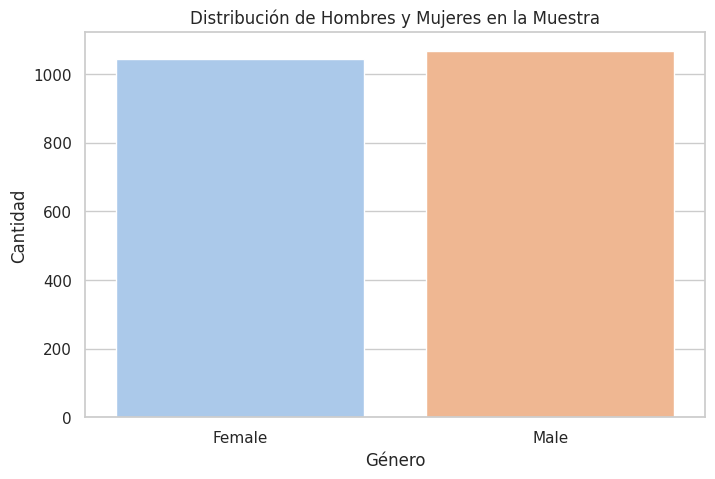

In [7]:
plt.figure(figsize=(8, 5))
# Agregamos hue='Gender' y legend=False para evitar el FutureWarning
sns.countplot(data=df, x='Gender', hue='Gender', palette='pastel', legend=False)
plt.title('Distribución de Hombres y Mujeres en la Muestra')
plt.xlabel('Género')
plt.ylabel('Cantidad')
plt.show()

El gráfico muestra que la cantidad de hombres y mujeres encuestados es casi idéntica. Esto significa que la muestra está muy equilibrada y representa a ambos géneros por igual.

b. Estudiar la proporción de consumidores de alcohol mujeres y hombres
Para ver la relación entre dos variables categóricas, podemos usar un gráfico de barras agrupado.  

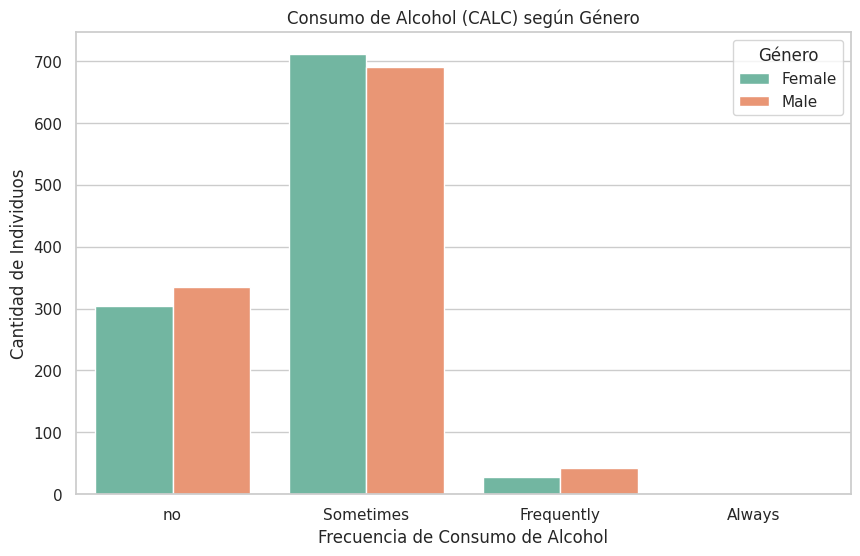

In [8]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='CALC', hue='Gender', palette='Set2')
plt.title('Consumo de Alcohol (CALC) según Género')
plt.xlabel('Frecuencia de Consumo de Alcohol')
plt.ylabel('Cantidad de Individuos')
plt.legend(title='Género')
plt.show()

La mayoría de las personas (tanto hombres como mujeres) respondieron que consumen alcohol "A veces" (Sometimes) o "No" consumen. Las opciones "Frecuentemente" (Frequently) o "Siempre" (Always) fueron muy poco elegidas por ambos grupos.

c. Estudiar la relación entre la edad y el peso
Como vimos en la teoría, para estudiar cómo se relacionan o impactan dos variables cuantitativas continuas, lo ideal es un diagrama de dispersión (scatter plot)

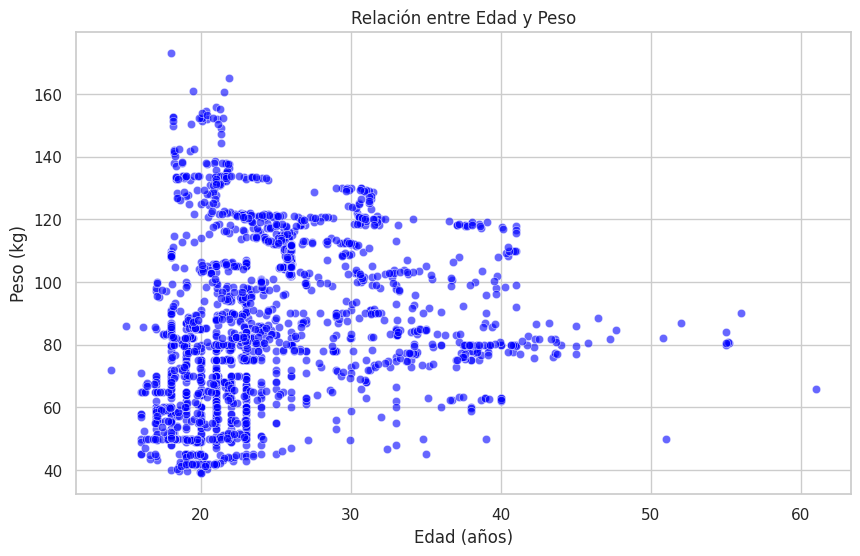

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Weight', alpha=0.6, color='blue')
plt.title('Relación entre Edad y Peso')
plt.xlabel('Edad (años)')
plt.ylabel('Peso (kg)')
plt.show()

Los puntos están muy dispersos y no forman una línea clara, lo que indica que no hay una relación directa o fuerte entre la edad y el peso. Hay personas de distintas edades pesando casi lo mismo, y personas de la misma edad con pesos muy diferentes.

d. Estudiar la relación entre peso y altura
Nuevamente, un diagrama de dispersión es la herramienta adecuada para cruzar estas dos variables cuantitativas.  

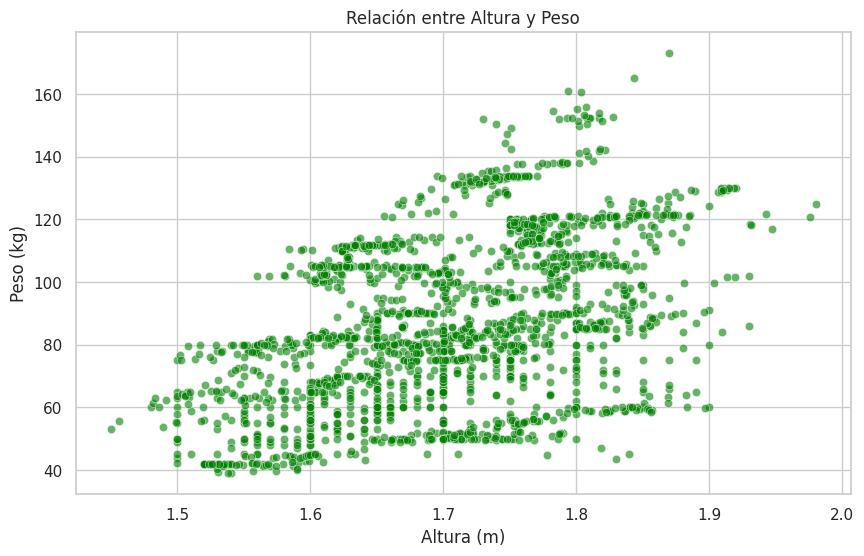

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Height', y='Weight', alpha=0.6, color='green')
plt.title('Relación entre Altura y Peso')
plt.xlabel('Altura (m)')
plt.ylabel('Peso (kg)')
plt.show()

Se observa una tendencia general ascendente: a medida que aumenta la altura, el peso también tiende a subir. Esto tiene sentido, ya que las personas más altas suelen pesar más, aunque hay bastante variación individual.

e. Estudiar la relación entre obesidad y consumo de alcohol
Ambas son variables categóricas. Una excelente práctica vista en la teoría es utilizar un mapa de calor (heatmap) de proporciones basado en una tabla de contingencia.

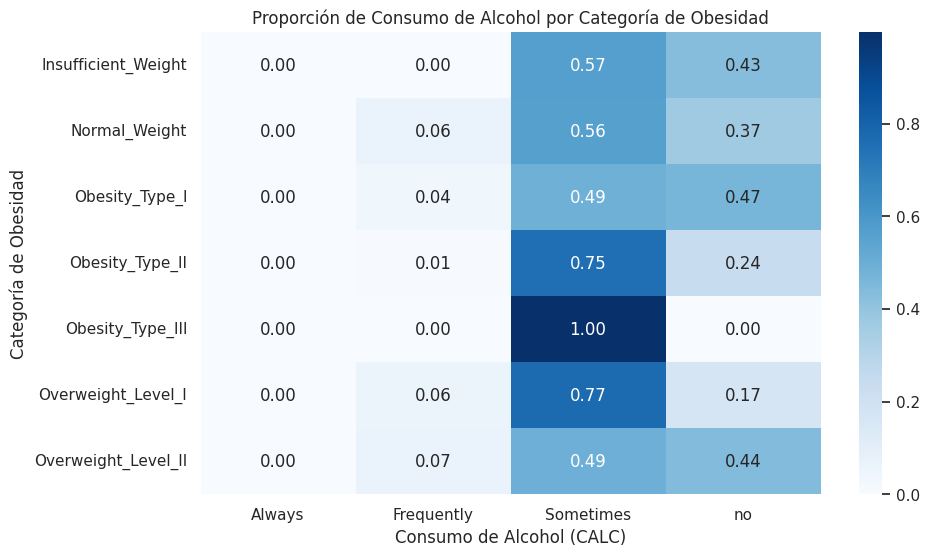

In [11]:
plt.figure(figsize=(10, 6))
# Creamos una tabla de contingencia normalizada por filas para ver proporciones
contingency_table = pd.crosstab(df['NObeyesdad'], df['CALC'], normalize='index')

sns.heatmap(contingency_table, annot=True, cmap='Blues', fmt='.2f')
plt.title('Proporción de Consumo de Alcohol por Categoría de Obesidad')
plt.xlabel('Consumo de Alcohol (CALC)')
plt.ylabel('Categoría de Obesidad')
plt.show()

Independientemente del nivel de obesidad, la gran mayoría de las personas consume alcohol "A veces". Destaca el caso de "Obesity_Type_III", donde el 100% (1.00) de la muestra indicó consumir alcohol solo "A veces".

f. Estudiar la proporción de edades en la muestra de mujeres y de hombres
Para comparar la distribución de una variable numérica separada por una categórica, la clase sugiere histogramas superpuestos o gráficos de violín. Usemos un histograma con estimación de densidad (KDE).

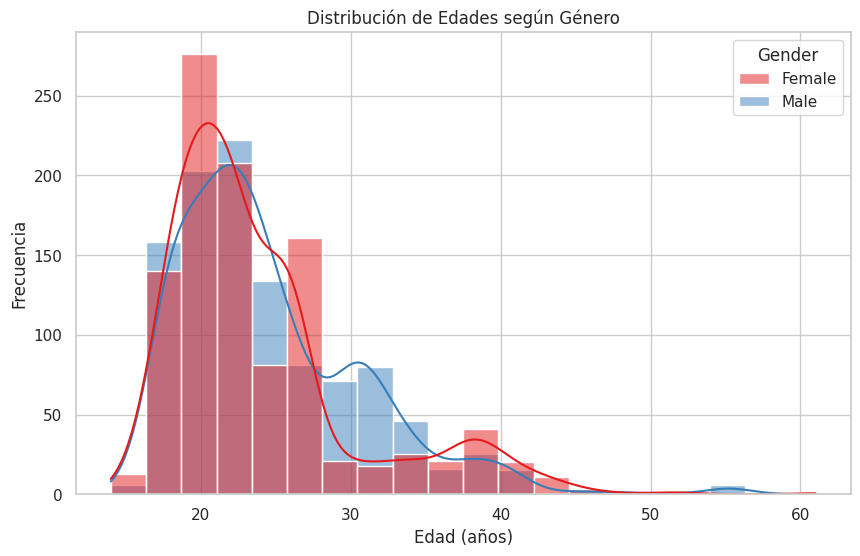

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Gender', kde=True, bins=20, palette='Set1', alpha=0.5)
plt.title('Distribución de Edades según Género')
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia')
plt.show()

Las edades se concentran fuertemente alrededor de los 20-25 años para ambos géneros, con muy pocas personas mayores de 40 años. Las distribuciones de hombres y mujeres son muy similares, con un pico de concentración casi idéntico.

g. Estudiar los valores de peso según la variable categoría de obesidad
El gráfico de cajas y bigotes (boxplot) es ideal aquí, porque nos permite ver rápidamente los cuartiles, la mediana y los valores atípicos (outliers) de una variable cuantitativa segmentada por categorías.

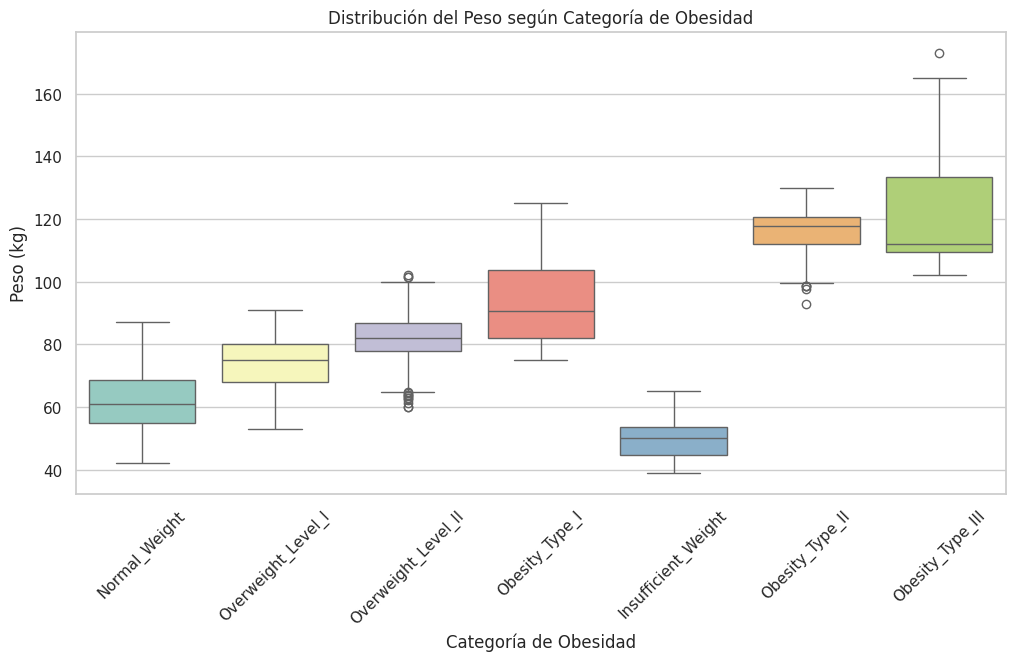

In [14]:
plt.figure(figsize=(12, 6))
# Agregamos hue='NObeyesdad' y legend=False
sns.boxplot(data=df, x='NObeyesdad', y='Weight', hue='NObeyesdad', palette='Set3', legend=False)
plt.title('Distribución del Peso según Categoría de Obesidad')
plt.xlabel('Categoría de Obesidad')
plt.ylabel('Peso (kg)')
plt.xticks(rotation=45) 
plt.show()

A medida que la categoría de obesidad es mayor, el peso central (mediana) lógicamente aumenta. Sin embargo, hay mucha superposición: personas con el mismo peso en kilogramos pueden pertenecer a categorías distintas (como "Normal" o "Sobrepeso"), ya que la obesidad no depende solo del peso sino también de la altura.

h. Estudiar la relación entre el consumo de vegetales y la obesidad
El consumo de vegetales (FCVC) es numérico y la obesidad categórica. Un gráfico de violín (violin plot) es una gran alternativa que combina el boxplot con un gráfico de densidad, tal como lo muestra el material teórico.  

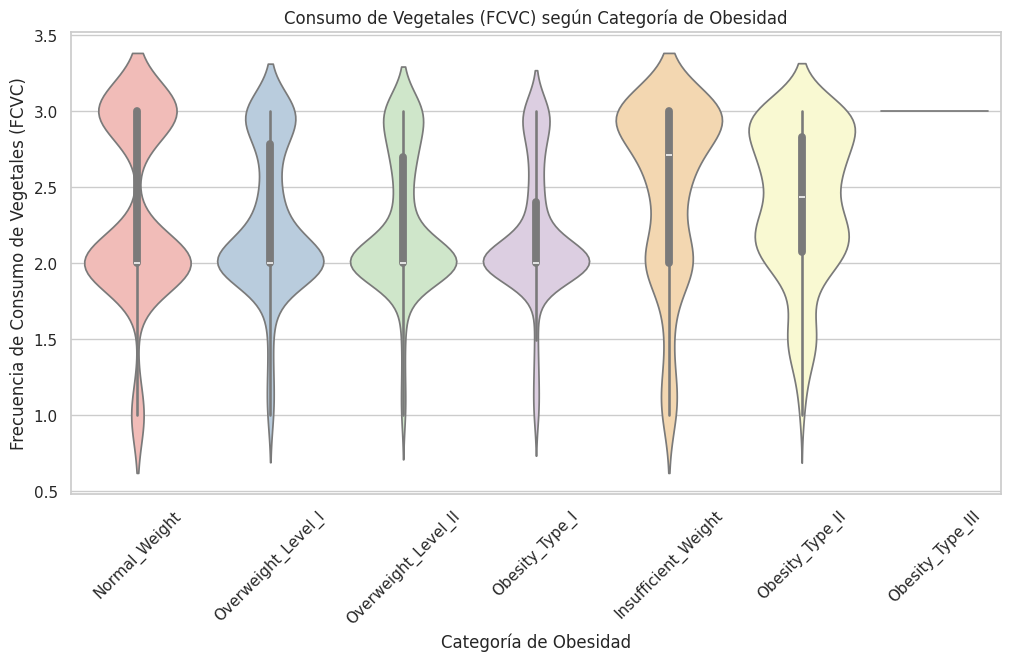

In [16]:
plt.figure(figsize=(12, 6))
# Agregamos hue='NObeyesdad' y legend=False
sns.violinplot(data=df, x='NObeyesdad', y='FCVC', hue='NObeyesdad', palette='Pastel1', legend=False)
plt.title('Consumo de Vegetales (FCVC) según Categoría de Obesidad')
plt.xlabel('Categoría de Obesidad')
plt.ylabel('Frecuencia de Consumo de Vegetales (FCVC)')
plt.xticks(rotation=45)
plt.show()

La mayoría de las personas reporta consumir vegetales con frecuencia media o alta (valores 2 y 3), sin importar su categoría de peso. La excepción es "Obesity_Type_III", que muestra una línea plana en 3, sugiriendo que todos los individuos de ese grupo tienen exactamente el mismo valor (probablemente un error o un dato generado artificialmente).

i. Proponer gráficas adicionales basándose en las sugerencias
Una de las mejores herramientas de análisis exploratorio para ver todas las relaciones numéricas de un vistazo es la Matriz de Correlación umbralizada con un Heatmap. Esto maximiza el "data-ink ratio" al ocultar la diagonal redundante y enfocarse en las relaciones fuertes.  

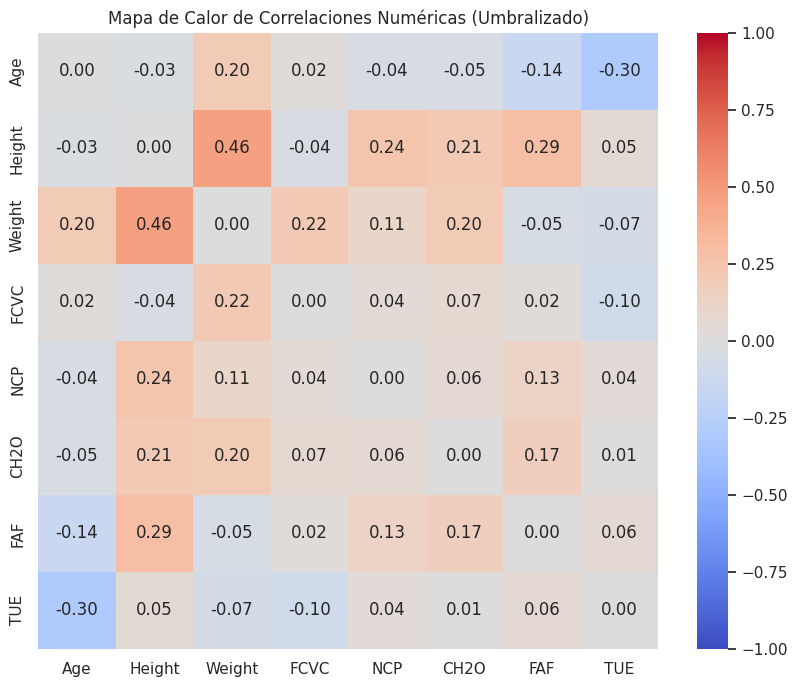

In [17]:
import numpy as np

plt.figure(figsize=(10, 8))
# Seleccionamos solo las variables numéricas
numerics = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numerics.corr()

# Umbralizamos para ver correlaciones fuertes (ej. > 0.6 o < -0.6)
# y ocultamos la diagonal para reducir ruido visual
corr_matrix_umbralizada = corr_matrix.copy()
np.fill_diagonal(corr_matrix_umbralizada.values, 0)

sns.heatmap(corr_matrix_umbralizada, vmin=-1.0, vmax=1.0, center=0.0, 
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor de Correlaciones Numéricas (Umbralizado)')
plt.show()

Este mapa muestra qué tanto se relacionan las variables numéricas entre sí (valores cercanos a 1 o -1 indican fuerte relación). Se ve que la única relación moderadamente fuerte (0.46) es entre el Peso y la Altura, mientras que el resto de las variables casi no se influyen mutuamente.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética opcional
sns.set_theme(style="whitegrid")

# Cargar el dataset (si te da error de decodificación, el parámetro encoding lo soluciona)
df = pd.read_csv("netflix_titles.csv", encoding='latin-1')

a. y b. Películas y TV Shows por Año de Lanzamiento
Podemos usar histogramas para ver la distribución histórica de manera muy clara.

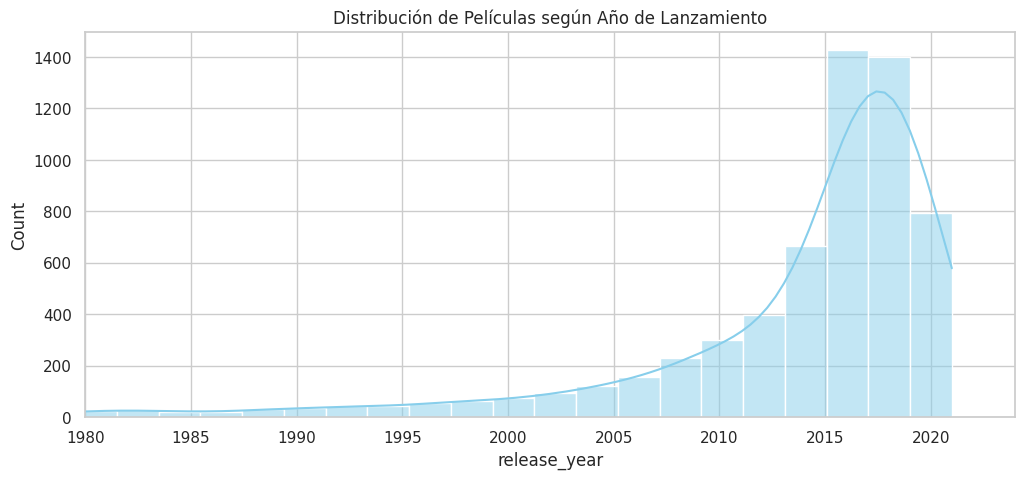

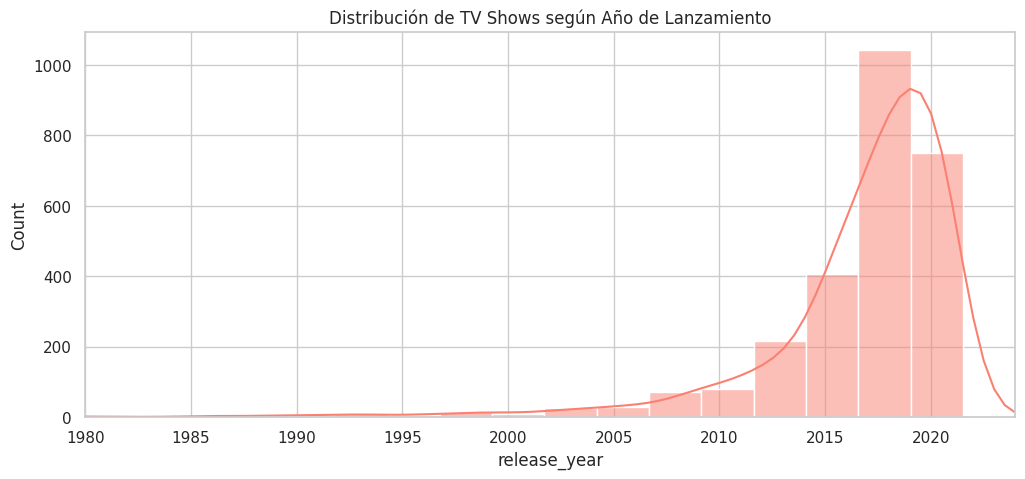

In [19]:
plt.figure(figsize=(12, 5))
# Filtramos películas
movies = df[df['type'] == 'Movie']
sns.histplot(data=movies, x='release_year', bins=40, color='skyblue', kde=True)
plt.title('Distribución de Películas según Año de Lanzamiento')
plt.xlim(1980, 2024)
plt.show()

plt.figure(figsize=(12, 5))
# Filtramos TV Shows
tv_shows = df[df['type'] == 'TV Show']
sns.histplot(data=tv_shows, x='release_year', bins=40, color='salmon', kde=True)
plt.title('Distribución de TV Shows según Año de Lanzamiento')
plt.xlim(1980, 2024)
plt.show()

Análisis: Ambas gráficas muestran un crecimiento exponencial hacia los años recientes (2015-2021). Netflix prioriza claramente contenido moderno sobre los clásicos en ambos formatos.

c. Cantidad de contenidos según su Rating
Usamos un gráfico de barras agrupado para comparar ambos formatos de manera directa.

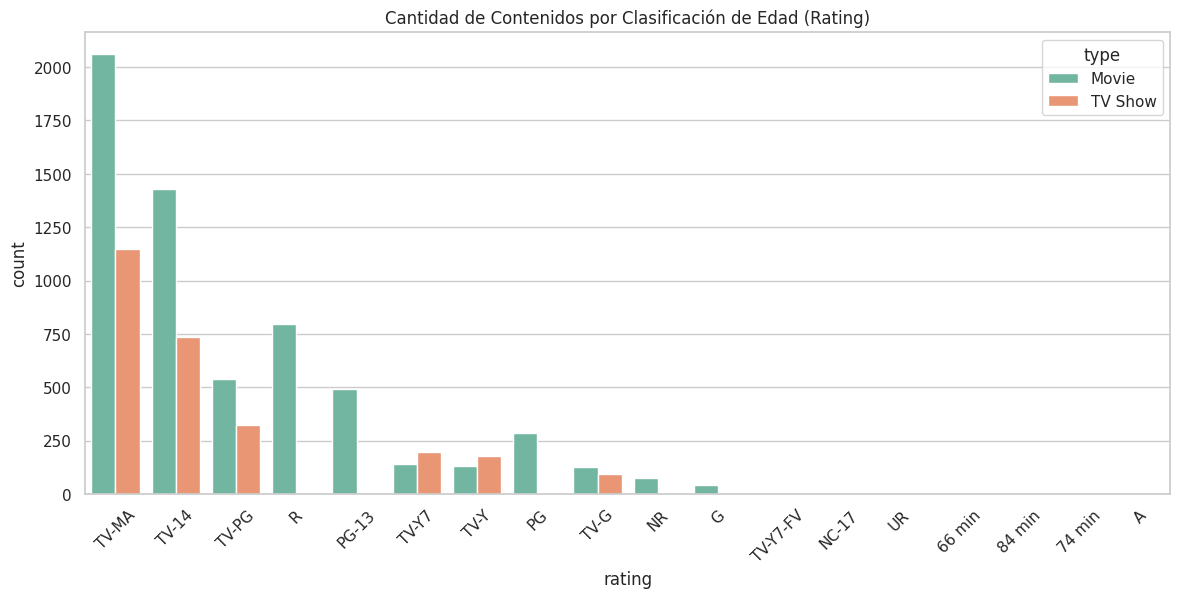

In [20]:
plt.figure(figsize=(14, 6))
order = df['rating'].value_counts().index
sns.countplot(data=df, x='rating', hue='type', palette='Set2', order=order)
plt.title('Cantidad de Contenidos por Clasificación de Edad (Rating)')
plt.xticks(rotation=45)
plt.show()

Análisis: El contenido mayoritario es TV-MA (para adultos), seguido de TV-14. Hay una clara orientación en el catálogo hacia el público maduro y adolescente.

d. Relación entre Rating y Duración (Películas)
Primero debemos extraer el valor numérico de la duración (que está en formato texto, ej. "90 min").

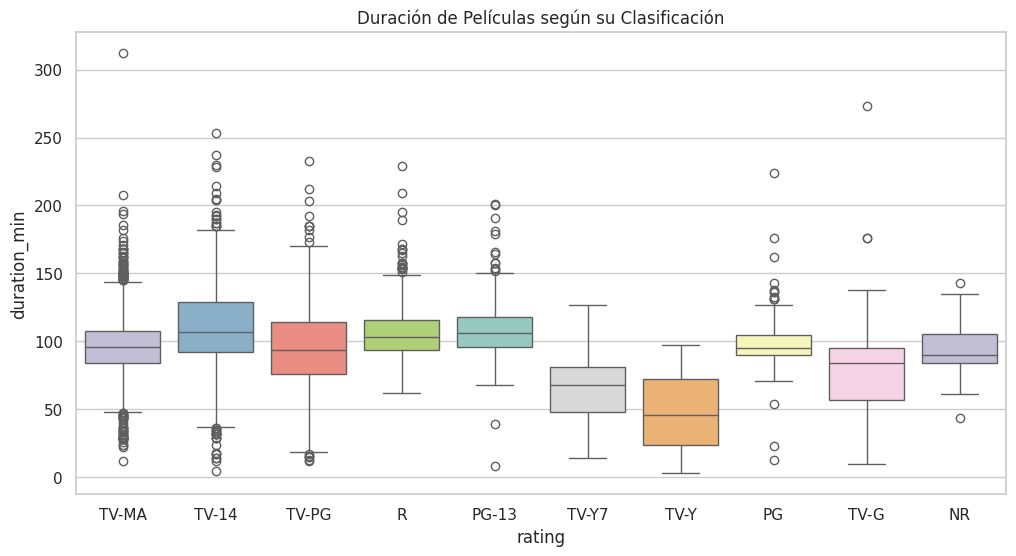

In [21]:
movies_df = df[df['type'] == 'Movie'].copy()
movies_df['duration_min'] = movies_df['duration'].str.extract(r'(\d+)').astype(float)

plt.figure(figsize=(12, 6))
sns.boxplot(data=movies_df, x='rating', y='duration_min', palette='Set3', order=order[:10], hue='rating', legend=False)
plt.title('Duración de Películas según su Clasificación')
plt.show()

Análisis: Las películas para adultos (TV-MA, R) tienden a ser ligeramente más largas en su mediana que las películas infantiles (TV-Y, TV-Y7).

e. Longitud de descripción y Rating
Aquí hay un pequeño detalle a tener en cuenta: en Netflix, el "Rating" no se refiere a la puntuación o valoración de calidad del público (ej. 8/10 estrellas), sino a la clasificación por edad (TV-MA, PG-13, etc.). Por lo tanto, no podemos saber si están "mejor votadas" con esta columna, pero sí podemos analizar si la extensión del texto varía según el público al que va dirigido.

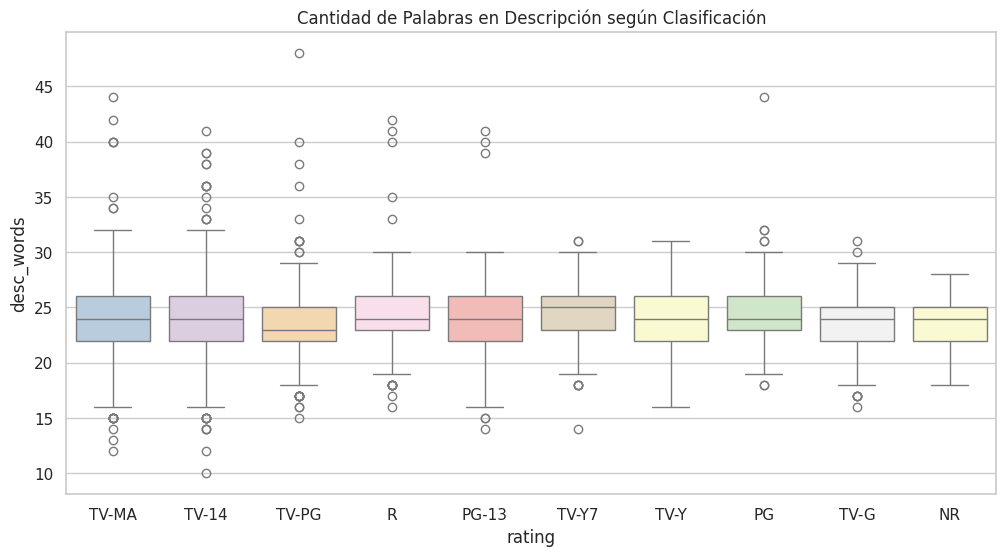

In [22]:
df_desc = df.copy()
df_desc['desc_words'] = df_desc['description'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_desc, x='rating', y='desc_words', palette='Pastel1', order=order[:10], hue='rating', legend=False)
plt.title('Cantidad de Palabras en Descripción según Clasificación')
plt.show()

Análisis: La longitud es sorprendentemente uniforme en sus medianas (alrededor de 24 palabras) para todas las clasificaciones de edad. Evidentemente, Netflix aplica una regla de estilo estricta para limitar el texto de las sinopsis.

Contenidos por País (Top 10)

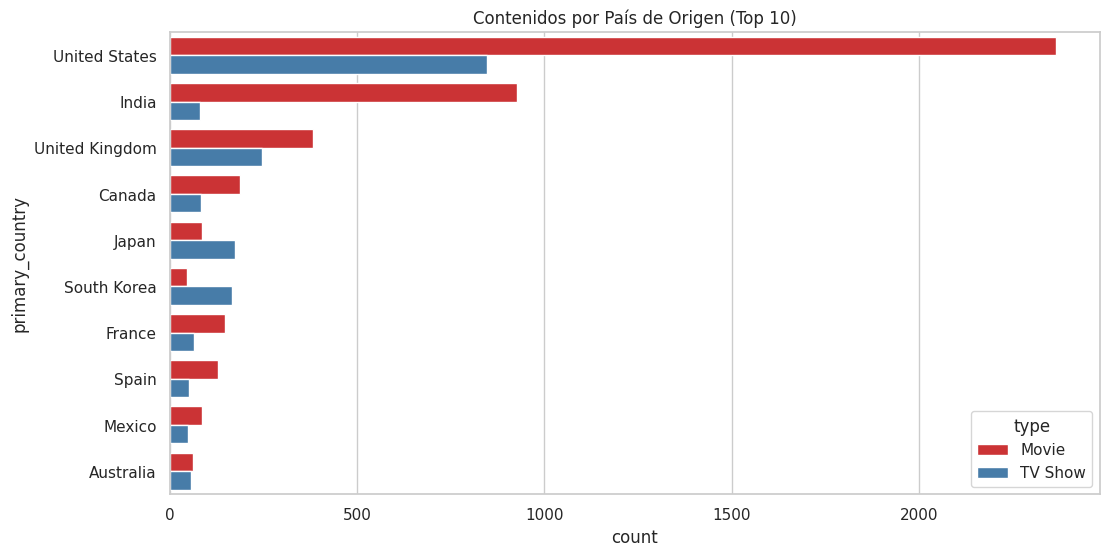

In [23]:
# Tomamos el primer país de la lista (a veces hay co-producciones separadas por comas)
df_country = df.copy()
df_country['primary_country'] = df_country['country'].apply(lambda x: str(x).split(',')[0] if pd.notnull(x) else None)
top_countries = df_country['primary_country'].value_counts().head(10).index

plt.figure(figsize=(12, 6))
sns.countplot(data=df_country[df_country['primary_country'].isin(top_countries)], 
              y='primary_country', hue='type', order=top_countries, palette='Set1')
plt.title('Contenidos por País de Origen (Top 10)')
plt.show()

Análisis: Estados Unidos es el líder indiscutido. Llama la atención el enorme volumen de películas provenientes de India, superando de manera abrumadora a sus series.

In [ ]:
Actores con más apariciones (Top 10)

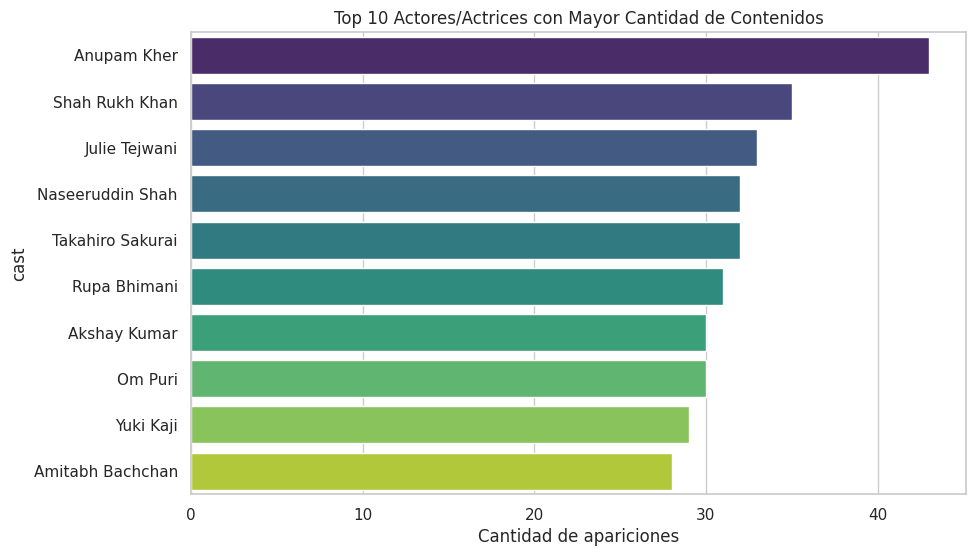

In [24]:
plt.figure(figsize=(10, 6))
# Separamos los actores de la lista delimitada por comas para poder contarlos individualmente
cast_series = df['cast'].dropna().str.split(', ').explode()
top_actors = cast_series.value_counts().head(10)

sns.barplot(x=top_actors.values, y=top_actors.index, hue=top_actors.index, palette='viridis', legend=False)
plt.title('Top 10 Actores/Actrices con Mayor Cantidad de Contenidos')
plt.xlabel('Cantidad de apariciones')
plt.show()

Análisis: La mayoría del Top 10 está compuesto por estrellas de Bollywood (como Anupam Kher o Shah Rukh Khan) y actores de doblaje, lo que concuerda con la altísima producción de películas de la India vista en el punto anterior.

h. Gráfica adicional sugerida: Evolución Temporal
Siguiendo las buenas prácticas teóricas del apunte, cuando hay variables de tiempo, un gráfico de líneas es excelente para mostrar tendencias y comparar series de forma clara.

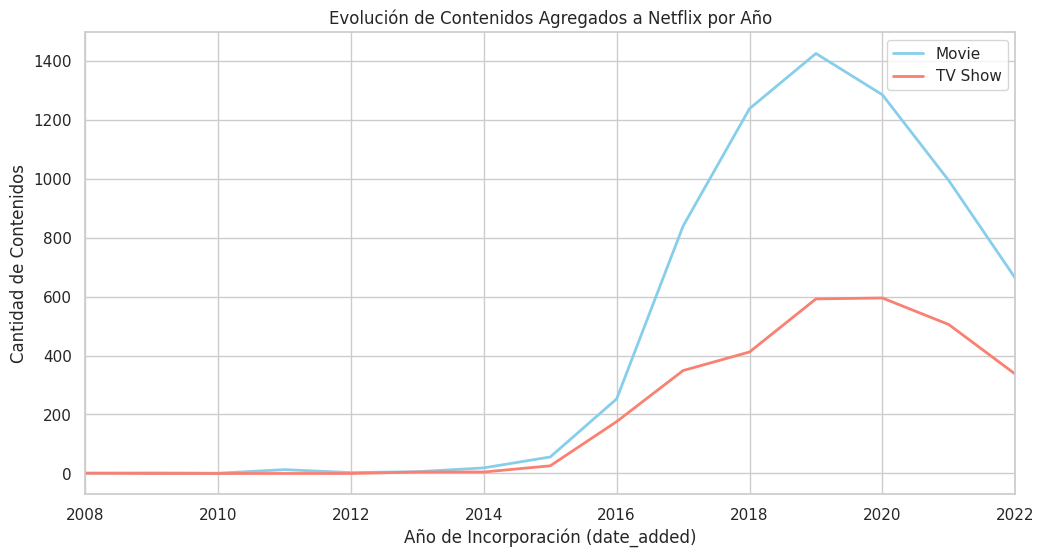

In [25]:
df_time = df.copy()
df_time['date_added'] = pd.to_datetime(df_time['date_added'].str.strip(), errors='coerce')
df_time['year_added'] = df_time['date_added'].dt.year
trend = df_time.groupby(['year_added', 'type']).size().unstack().fillna(0)

plt.figure(figsize=(12, 6))
plt.plot(trend.index, trend['Movie'], label='Movie', color='skyblue', linewidth=2)
plt.plot(trend.index, trend['TV Show'], label='TV Show', color='salmon', linewidth=2)
plt.title('Evolución de Contenidos Agregados a Netflix por Año')
plt.xlabel('Año de Incorporación (date_added)')
plt.ylabel('Cantidad de Contenidos')
plt.xlim(2008, 2022)
plt.legend()
plt.show()

Análisis: El gráfico ilustra el crecimiento explosivo de la plataforma entre 2016 y 2019, y cómo la incorporación de películas cayó drásticamente durante el 2020-2021 (probablemente por la pandemia), mientras que las series se mantuvieron más estables.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set_theme(style="whitegrid")

# Cargar el dataset
df = pd.read_csv("food_coded.csv")

# --- LIMPIEZA DE DATOS (Visto en Práctica 4) ---
# Convertimos GPA y weight a valores numéricos, los textos inválidos se vuelven NaN
df['GPA_clean'] = pd.to_numeric(df['GPA'], errors='coerce')
df['weight_clean'] = pd.to_numeric(df['weight'], errors='coerce')

# Mapeamos el Género según el codebook (1: Femenino, 2: Masculino) para mayor claridad
df['Gender_label'] = df['Gender'].map({1: 'Femenino', 2: 'Masculino'})

a. Estudiar la distribución de algunos valores de variable en la muestra
Utilizamos un histograma para visualizar cómo se distribuyen los valores continuos del peso en la muestra.  

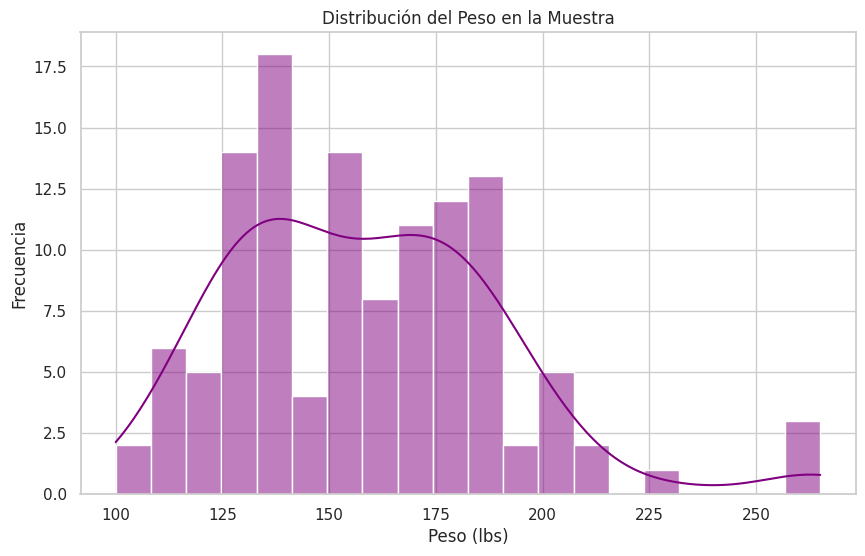

In [27]:
plt.figure(figsize=(10, 6))
# Histograma con curva de densidad (KDE)
sns.histplot(data=df, x='weight_clean', bins=20, kde=True, color='purple')
plt.title('Distribución del Peso en la Muestra')
plt.xlabel('Peso (lbs)')
plt.ylabel('Frecuencia')
plt.show()

Análisis:
El gráfico muestra la concentración principal del peso de los encuestados. La distribución tiene un sesgo hacia la izquierda (asimetría positiva), indicando que la mayoría de los estudiantes agrupan su peso entre las 130 y 160 libras, con muy pocos casos superando las 200 libras.

b. Estudiar la relación entre dos variables cuantitativas
Un gráfico de dispersión (scatter plot) es la herramienta ideal vista en la teoría para contrastar dos variables numéricas, en este caso, el Peso y el Promedio Académico (GPA).  

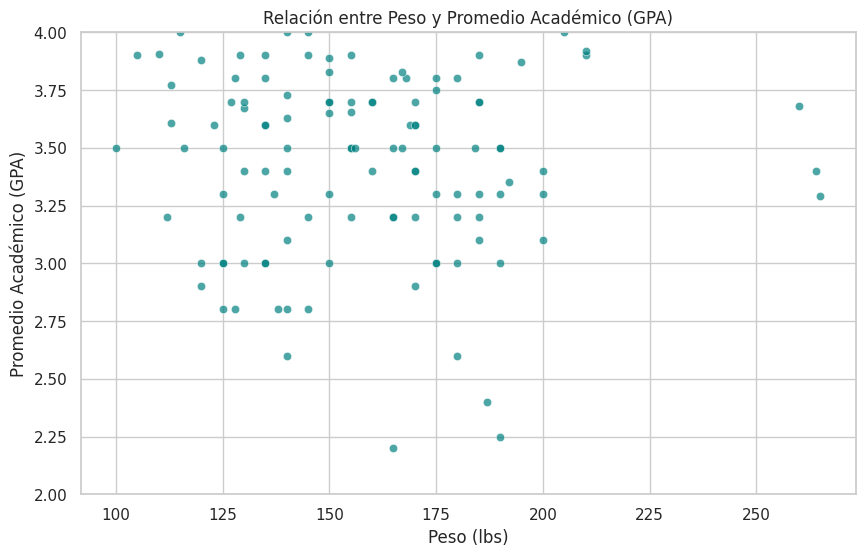

In [28]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='weight_clean', y='GPA_clean', alpha=0.7, color='teal')
plt.title('Relación entre Peso y Promedio Académico (GPA)')
plt.xlabel('Peso (lbs)')
plt.ylabel('Promedio Académico (GPA)')
# Limitamos el eje Y para evitar outliers extremos en GPA que distorsionen el gráfico
plt.ylim(2.0, 4.0) 
plt.show()

Análisis:
Los puntos se ven dispersos aleatoriamente a lo largo de todo el plano sin formar ninguna línea o tendencia clara. Esto indica que no existe una correlación aparente entre el peso físico de un estudiante y su rendimiento académico.

c. Estudiar relaciones entre dos variables cualitativas
Creamos un mapa de calor (heatmap) sobre una tabla de contingencia para relacionar el Género con la frecuencia con la que cocinan (cook).

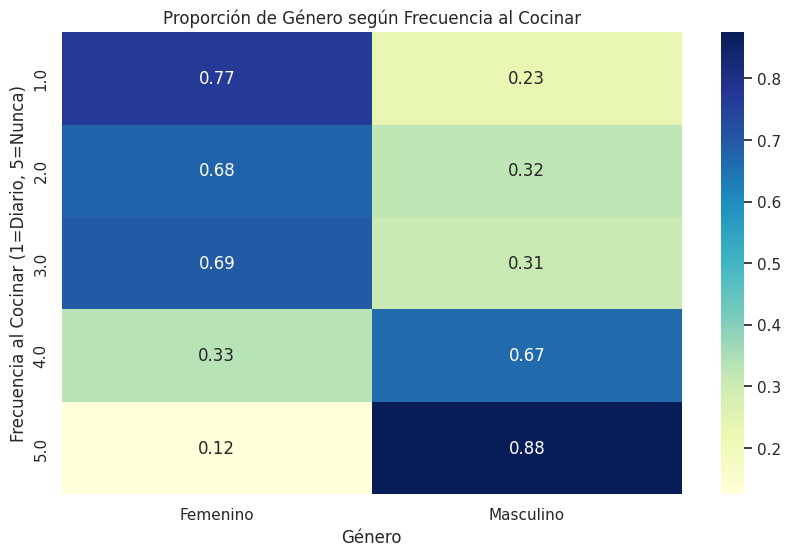

In [29]:
plt.figure(figsize=(10, 6))
# Tabla cruzada normalizada para ver porcentajes. 
# Cook: 1=Todos los días, 5=Nunca.
contingency = pd.crosstab(df['cook'], df['Gender_label'], normalize='index')

sns.heatmap(contingency, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Proporción de Género según Frecuencia al Cocinar')
plt.xlabel('Género')
plt.ylabel('Frecuencia al Cocinar (1=Diario, 5=Nunca)')
plt.show()

Análisis:
El mapa de calor revela que las mujeres (Femenino) dominan ampliamente las categorías de quienes cocinan "todos los días" (1.0), mientras que la proporción de hombres aumenta considerablemente en las categorías de quienes cocinan solo en vacaciones (4.0) o "nunca" (5.0).

d. Proponer gráficas adicionales basándose en las sugerencias
Un gráfico de violín es una sugerencia excelente de la teoría para mostrar la distribución de una variable cuantitativa (Peso) dividida en grupos categóricos (Género). Combina un diagrama de cajas con la densidad de los datos.

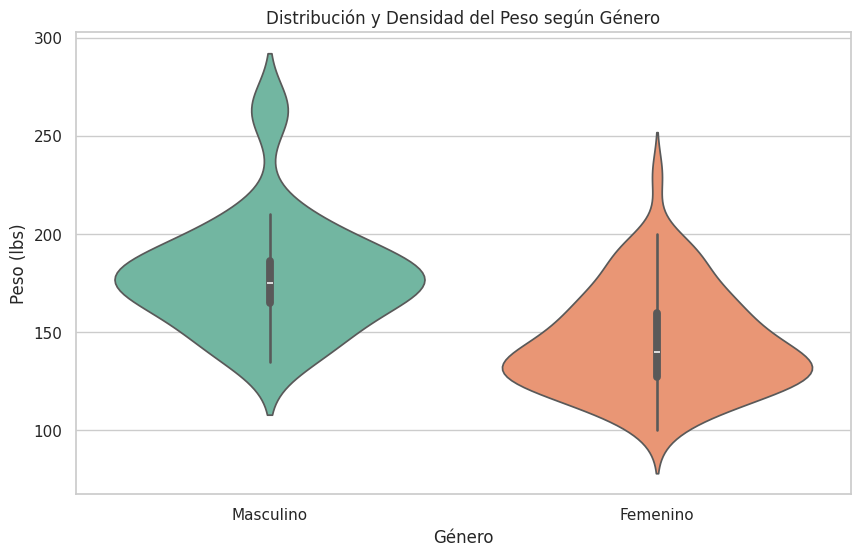

In [30]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Gender_label', y='weight_clean', hue='Gender_label', palette='Set2')
plt.title('Distribución y Densidad del Peso según Género')
plt.xlabel('Género')
plt.ylabel('Peso (lbs)')
plt.show()

Análisis:
El violín masculino se ubica visiblemente más arriba en el eje Y, confirmando que la mediana del peso en hombres es mayor que en mujeres. Además, el "bulto" principal del violín femenino es más ancho y corto, lo que indica que el peso de las mujeres está mucho más agrupado y tiene menos variación que el de los hombres.